In [25]:
import sklearn
print(sklearn.__version__)

1.9.0


In [26]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [27]:
df = pd.read_csv("car_details.csv")

df.head()

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [28]:
df.shape

(15411, 14)

In [29]:
df.columns

Index(['Unnamed: 0', 'car_name', 'brand', 'model', 'vehicle_age', 'km_driven',
       'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine',
       'max_power', 'seats', 'selling_price'],
      dtype='object')

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         15411 non-null  int64  
 1   car_name           15411 non-null  object 
 2   brand              15411 non-null  object 
 3   model              15411 non-null  object 
 4   vehicle_age        15411 non-null  int64  
 5   km_driven          15411 non-null  int64  
 6   seller_type        15411 non-null  object 
 7   fuel_type          15411 non-null  object 
 8   transmission_type  15411 non-null  object 
 9   mileage            15411 non-null  float64
 10  engine             15411 non-null  int64  
 11  max_power          15411 non-null  float64
 12  seats              15411 non-null  int64  
 13  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(6), object(6)
memory usage: 1.6+ MB


In [31]:
df.isnull().sum()

Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

In [32]:
numerical_cols = df.select_dtypes(include=['int64','float64']).columns

for col in numerical_cols:
    df[col].fillna(df[col].median(), inplace=True)

C:\Users\J KRISH\AppData\Local\Temp\ipykernel_28136\1574676182.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\J KRISH\AppData\Local\Temp\ipykernel_28136\1574676182.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For e

In [33]:
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

C:\Users\J KRISH\AppData\Local\Temp\ipykernel_28136\3199972163.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [34]:
df.duplicated().sum()

np.int64(0)

In [35]:
df.drop_duplicates(inplace=True)

In [36]:
df[['mileage','engine','max_power']].dtypes

mileage      float64
engine         int64
max_power    float64
dtype: object

In [37]:
df.drop('Unnamed: 0', axis=1, inplace=True)

In [38]:
df.head()

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [39]:
encoder = LabelEncoder()

categorical_columns = [
    'car_name',
    'brand',
    'model',
    'seller_type',
    'fuel_type',
    'transmission_type'
]


for col in categorical_columns:
    df[col] = encoder.fit_transform(df[col])

In [40]:
df.select_dtypes(include='object').columns

Index([], dtype='object')

In [41]:
y = df['selling_price']

In [42]:
X = df.drop('selling_price', axis=1)

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [44]:
print(X.shape)
print(y.shape)

(15411, 12)
(15411,)


In [45]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [46]:
lr = LinearRegression()

lr.fit(
    X_train,
    y_train
)

lr_prediction = lr.predict(X_test)

In [47]:
dt = DecisionTreeRegressor(
    random_state=42
)

dt.fit(
    X_train,
    y_train
)

dt_prediction = dt.predict(X_test)

In [48]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

rf_prediction = rf.predict(X_test)

In [49]:
def evaluate_model(y_test, prediction):

    mae = mean_absolute_error(
        y_test,
        prediction
    )

    mse = mean_squared_error(
        y_test,
        prediction
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        y_test,
        prediction
    )

    return mae, mse, rmse, r2

In [50]:
results = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "MAE":[
        evaluate_model(y_test,lr_prediction)[0],
        evaluate_model(y_test,dt_prediction)[0],
        evaluate_model(y_test,rf_prediction)[0]
    ],

    "MSE":[
        evaluate_model(y_test,lr_prediction)[1],
        evaluate_model(y_test,dt_prediction)[1],
        evaluate_model(y_test,rf_prediction)[1]
    ],

    "RMSE":[
        evaluate_model(y_test,lr_prediction)[2],
        evaluate_model(y_test,dt_prediction)[2],
        evaluate_model(y_test,rf_prediction)[2]
    ],

    "R2 Score":[
        evaluate_model(y_test,lr_prediction)[3],
        evaluate_model(y_test,dt_prediction)[3],
        evaluate_model(y_test,rf_prediction)[3]
    ]

})


results

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,270049.783437,2.506032e+11,500602.875130,0.667097
1,Decision Tree,123419.577792,9.076175e+10,301266.907370,0.879432
2,Random Forest,99264.666823,4.445179e+10,210835.936736,0.940950


In [51]:
results.sort_values(
    by="R2 Score",
    ascending=False
)

,Model,MAE,MSE,RMSE,R2 Score
2,Random Forest,99264.666823,4.445179e+10,210835.936736,0.940950
1,Decision Tree,123419.577792,9.076175e+10,301266.907370,0.879432
0,Linear Regression,270049.783437,2.506032e+11,500602.875130,0.667097


In [52]:
df.head()

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,65,18,7,9,120000,1,4,1,19.70,796,46.30,5,120000
1,34,8,54,5,20000,1,4,1,18.90,1197,82.00,5,550000
2,40,8,118,11,60000,1,4,1,17.00,1197,80.00,5,215000
3,65,18,7,9,37000,1,4,1,20.92,998,67.10,5,226000
4,20,6,38,6,30000,0,1,1,22.77,1498,98.59,5,570000


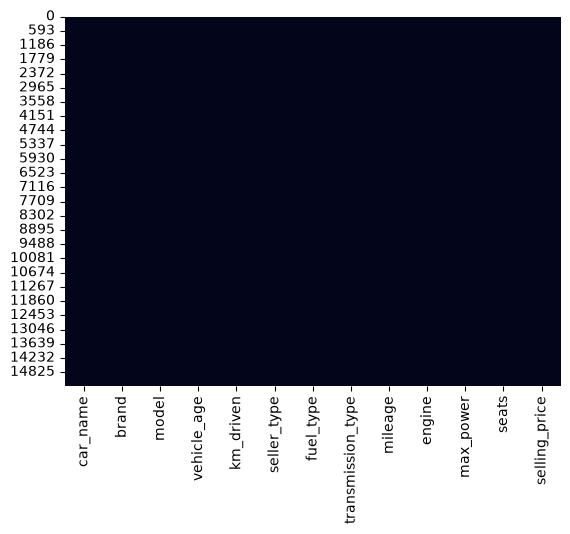

In [53]:
sns.heatmap(df.isnull(), cbar=False)
plt.show()

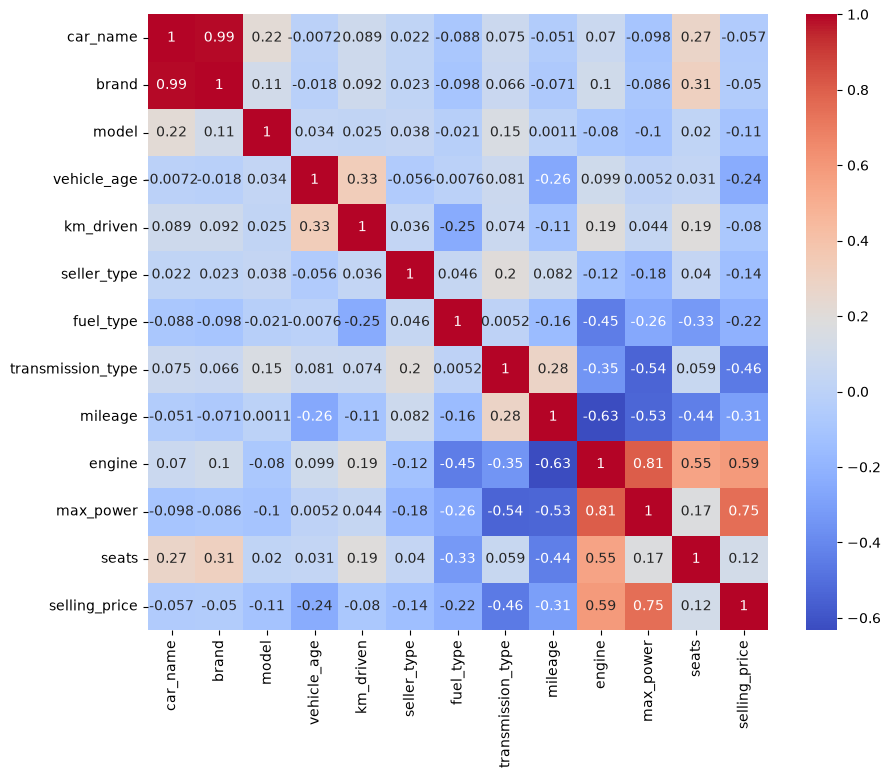

In [54]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [55]:
results

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,270049.783437,2.506032e+11,500602.875130,0.667097
1,Decision Tree,123419.577792,9.076175e+10,301266.907370,0.879432
2,Random Forest,99264.666823,4.445179e+10,210835.936736,0.940950


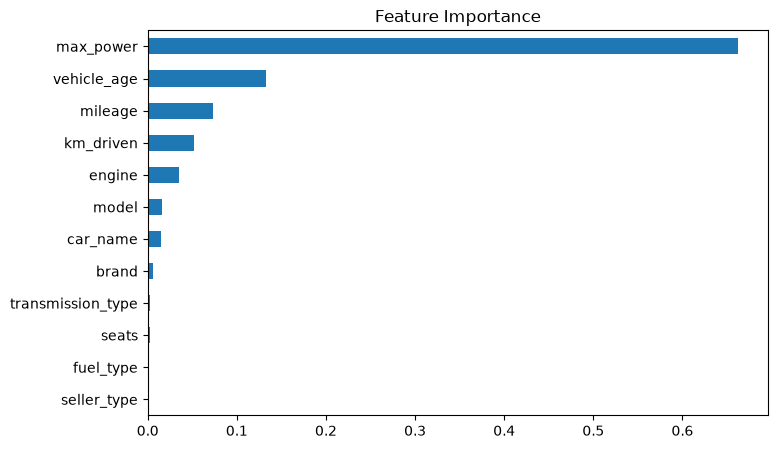

In [56]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(
    kind='barh',
    figsize=(8,5)
)

plt.title("Feature Importance")
plt.show()

## Conclusion

Three regression models were implemented:
1. Linear Regression
2. Decision Tree Regressor
3. Random Forest Regressor

The models were evaluated using MAE, MSE, RMSE, and R² Score.

Random Forest generally performs better because it can capture complex nonlinear relationships between car features and prices while reducing overfitting through ensemble learning.

Future improvements:
- Hyperparameter tuning using GridSearchCV
- Feature selection techniques
- Testing advanced models like XGBoost and Gradient Boosting